# CNN Assignment - 2
**Student ID:** 22-48056-2  
**Dataset:** CIFAR-10 (10-class image classification)  
**Framework:** PyTorch  

## 1. Import Libraries

In [1]:
# Core
import os
import time
import random
import numpy as np

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary

# Evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device (CPU only because i didn't have a Nvidia GPU available)
device = torch.device('cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


## 2. Load and Explore Dataset

**Dataset:** CIFAR-10  
- 60,000 color images (32×32 RGB)  
- 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck  
- 50,000 training images, 10,000 test images  

We load raw (un-normalized) data first just for exploration and visualization.

In [2]:
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')
NUM_CLASSES = len(CLASSES)

# Load raw dataset for exploration (no normalization yet)
raw_transform = transforms.ToTensor()
raw_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                          download=True, transform=raw_transform)
raw_test  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                          download=True, transform=raw_transform)

print(f"Training samples : {len(raw_train)}")
print(f"Test samples     : {len(raw_test)}")
print(f"Image shape      : {raw_train[0][0].shape}  (C x H x W)")
print(f"Classes          : {CLASSES}")

100%|██████████| 170M/170M [08:37<00:00, 330kB/s]  


Training samples : 50000
Test samples     : 10000
Image shape      : torch.Size([3, 32, 32])  (C x H x W)
Classes          : ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


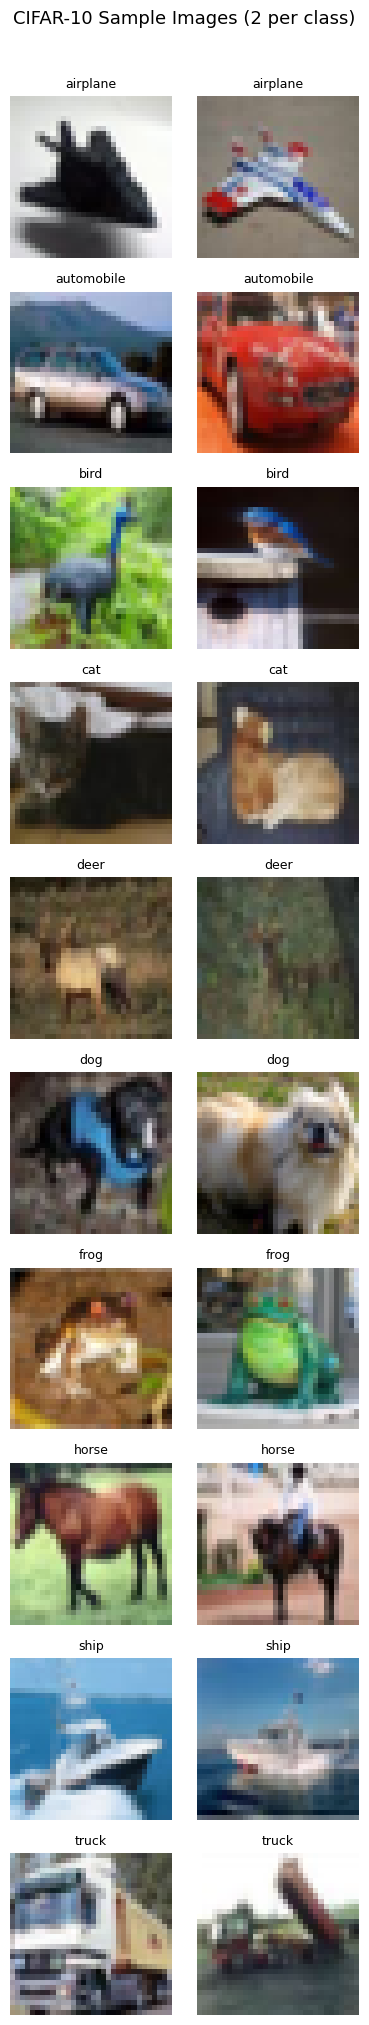

Saved: sample_images.png


In [3]:
# Visualize sample images (2 per class)
fig, axes = plt.subplots(NUM_CLASSES, 2, figsize=(4, 20))
fig.suptitle('CIFAR-10 Sample Images (2 per class)', fontsize=13, y=1.01)

shown = {c: 0 for c in range(NUM_CLASSES)}
for img, label in raw_train:
    if shown[label] < 2:
        ax = axes[label][shown[label]]
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(CLASSES[label], fontsize=9)
        ax.axis('off')
        shown[label] += 1
    if all(v == 2 for v in shown.values()):
        break

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: sample_images.png")

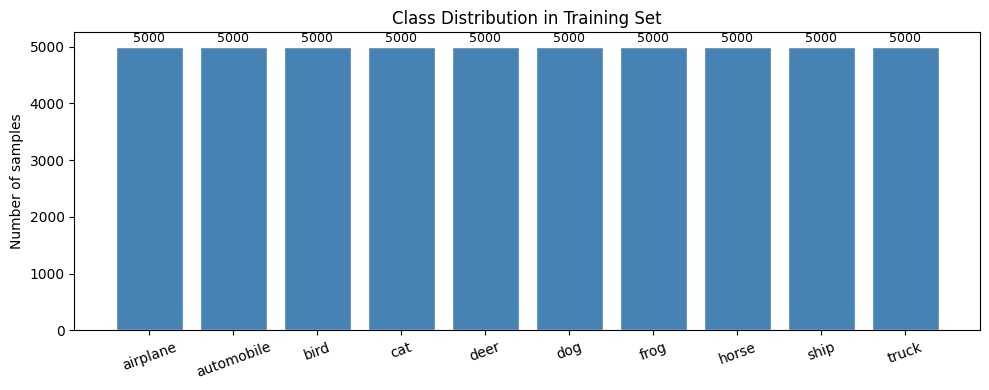

In [5]:
# Class distribution in training set
all_labels = [label for _, label in raw_train]
counts = [all_labels.count(i) for i in range(NUM_CLASSES)]

plt.figure(figsize=(10, 4))
bars = plt.bar(CLASSES, counts, color='steelblue', edgecolor='white')
plt.title('Class Distribution in Training Set')
plt.ylabel('Number of samples')
plt.xticks(rotation=20)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()

## 3. Data Preprocessing & Augmentation

**Strategy:**
- **Normalization:** Compute per-channel mean/std from the training set and standardize.
- **Training augmentation:**
  - `RandomCrop(32, padding=4)` : simulates translation invariance.
  - `RandomHorizontalFlip()` : doubles effective dataset size.
  - `ColorJitter` : adds mild color variation for robustness.
- **Validation/Test:** Only normalization (no augmentation) to get unbiased evaluation.
- **Split:** 45,000 train / 5,000 validation from original 50,000 training images.

**Hyperparameters:**
- Batch size: 64 (good balance of memory usage and gradient stability on CPU, i no have gpu :( )

In [6]:
# Compute mean and std from training data
loader_for_stats = DataLoader(raw_train, batch_size=500, shuffle=False, num_workers=0)
mean = torch.zeros(3)
std  = torch.zeros(3)
for imgs, _ in loader_for_stats:
    for c in range(3):
        mean[c] += imgs[:, c, :, :].mean()
        std[c]  += imgs[:, c, :, :].std()
mean /= len(loader_for_stats)
std  /= len(loader_for_stats)

MEAN = mean.tolist()
STD  = std.tolist()
print(f"Dataset mean : {[round(m, 4) for m in MEAN]}")
print(f"Dataset std  : {[round(s, 4) for s in STD]}")

Dataset mean : [0.4914, 0.4822, 0.4465]
Dataset std  : [0.2469, 0.2434, 0.2615]


In [7]:
#  Hyperparameters 
BATCH_SIZE   = 64
VAL_SPLIT    = 0.1   
NUM_WORKERS  = 0     

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Validation / test transforms (no augmentation)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Reload datasets with proper transforms
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=False, transform=train_transform)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=False, transform=eval_transform)

# Train / validation split
val_size   = int(len(full_train) * VAL_SPLIT)
train_size = len(full_train) - val_size
train_set, val_set = random_split(full_train, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(SEED))

# Apply eval transform to validation subset
val_set.dataset.transform = eval_transform

# DataLoaders
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches : {len(train_loader)}  ({train_size} samples)")
print(f"Val batches   : {len(val_loader)}  ({val_size} samples)")
print(f"Test batches  : {len(test_loader)}  ({len(test_set)} samples)")

Train batches : 704  (45000 samples)
Val batches   : 79  (5000 samples)
Test batches  : 157  (10000 samples)


## 4. Define CNN Architecture

### Design

We build a 3-block convolutional network followed by fully connected layers.

In [8]:
class CIFAR10_CNN(nn.Module):
    """
    Custom CNN for CIFAR-10 classification.
    
    Args:
        use_bn      : If True, apply BatchNorm after each Conv layer.
        use_dropout : If True, apply Dropout after each pooling block and before FC output.
    """
    def __init__(self, use_bn=True, use_dropout=True):
        super(CIFAR10_CNN, self).__init__()
        self.use_bn      = use_bn
        self.use_dropout = use_dropout

        # Block 1: 3 → 32 channels 
        self.conv1_1 = nn.Conv2d(3,  32, kernel_size=3, padding=1)
        self.bn1_1   = nn.BatchNorm2d(32)
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1_2   = nn.BatchNorm2d(32)
        self.pool1   = nn.MaxPool2d(kernel_size=2, stride=2)   # 32×32 → 16×16
        self.drop1   = nn.Dropout(0.25)

        # Block 2: 32 → 64 channels 
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2_1   = nn.BatchNorm2d(64)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2_2   = nn.BatchNorm2d(64)
        self.pool2   = nn.MaxPool2d(kernel_size=2, stride=2)   # 16×16 → 8×8
        self.drop2   = nn.Dropout(0.25)

        # Block 3: 64 → 128 channels 
        self.conv3_1 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.bn3_1   = nn.BatchNorm2d(128)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3_2   = nn.BatchNorm2d(128)
        self.pool3   = nn.MaxPool2d(kernel_size=2, stride=2)   # 8×8 → 4×4
        self.drop3   = nn.Dropout(0.25)

        # Fully Connected Layers 
        # After 3 max-pools: 32×32 → 4×4, so feature map = 128 * 4 * 4 = 2048
        self.fc1   = nn.Linear(128 * 4 * 4, 512)
        self.drop4 = nn.Dropout(0.5)
        self.fc2   = nn.Linear(512, NUM_CLASSES)

    def _apply_bn(self, x, bn_layer):
        """Apply BatchNorm only if enabled."""
        return bn_layer(x) if self.use_bn else x

    def _apply_drop(self, x, drop_layer):
        """Apply Dropout only if enabled."""
        return drop_layer(x) if self.use_dropout else x

    def forward(self, x):
        # Block 1
        x = F.relu(self._apply_bn(self.conv1_1(x), self.bn1_1))
        x = F.relu(self._apply_bn(self.conv1_2(x), self.bn1_2))
        x = self._apply_drop(self.pool1(x), self.drop1)

        # Block 2
        x = F.relu(self._apply_bn(self.conv2_1(x), self.bn2_1))
        x = F.relu(self._apply_bn(self.conv2_2(x), self.bn2_2))
        x = self._apply_drop(self.pool2(x), self.drop2)

        # Block 3
        x = F.relu(self._apply_bn(self.conv3_1(x), self.bn3_1))
        x = F.relu(self._apply_bn(self.conv3_2(x), self.bn3_2))
        x = self._apply_drop(self.pool3(x), self.drop3)

        # Flatten and FC
        x = x.view(x.size(0), -1)          # Flatten: (B, 128*4*4)
        x = F.relu(self.fc1(x))
        x = self._apply_drop(x, self.drop4)
        x = self.fc2(x)
        return x


# Instantiate both variants
model_with_reg    = CIFAR10_CNN(use_bn=True,  use_dropout=True).to(device)
model_without_reg = CIFAR10_CNN(use_bn=False, use_dropout=False).to(device)

print("Model WITH BatchNorm + Dropout:")
print(model_with_reg)
print(f"\nTotal parameters: {sum(p.numel() for p in model_with_reg.parameters()):,}")

Model WITH BatchNorm + Dropout:
CIFAR10_CNN(
  (conv1_1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1_1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1_2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1_2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv2_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2_1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (conv3_1): Conv2d(

In [10]:
# Detailed architecture summary
print("\n Architecture Summary (WITH BatchNorm + Dropout) ")
summary(model_with_reg, input_size=(3, 32, 32))


 Architecture Summary (WITH BatchNorm + Dropout) 
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
            Conv2d-3           [-1, 32, 32, 32]           9,248
       BatchNorm2d-4           [-1, 32, 32, 32]              64
         MaxPool2d-5           [-1, 32, 16, 16]               0
           Dropout-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]          18,496
       BatchNorm2d-8           [-1, 64, 16, 16]             128
            Conv2d-9           [-1, 64, 16, 16]          36,928
      BatchNorm2d-10           [-1, 64, 16, 16]             128
        MaxPool2d-11             [-1, 64, 8, 8]               0
          Dropout-12             [-1, 64, 8, 8]               0
           Conv2d-13            [-1, 128, 8, 8]     

## 5. Training Loop with Validation

### Hyperparameter Rationale

Optimizer - Adam -> Adaptive learning rate so faster convergence on CPU 

Learning rate - 1e-3 -> Standard Adam starting point 

Scheduler - CosineAnnealingLR -> Smoothly decays LR for better final accuracy than StepLR 

Loss - CrossEntropyLoss -> Standard for multi-class classification 

Epochs - 30 -> cuz CPU; avoids very long wait 

Batch size - 64 -> Memory efficient, stable gradients 

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=30, lr=1e-3, label=""):
    """
    Full training loop with validation.
    Returns history dict with train/val loss and accuracy per epoch.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}

    best_val_acc = 0.0
    best_weights = None

    print(f"\n{'='*60}")
    print(f"Training: {label}")
    print(f"{'='*60}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8} | {'LR':>8}")
    print('-' * 60)

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        #  Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100.0 * correct / total

        #  Validation Phase
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss_sum += loss.item() * imgs.size(0)
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_loss_sum / val_total
        val_acc  = 100.0 * val_correct / val_total

        # Save best weights
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        current_lr = scheduler.get_last_lr()[0]
        scheduler.step()

        elapsed = time.time() - t0
        print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
              f"{val_loss:>8.4f} | {val_acc:>7.2f}% | {current_lr:.6f}  ({elapsed:.0f}s)")

    print(f"\nBest validation accuracy: {best_val_acc:.2f}%")

    # Restore best weights
    model.load_state_dict(best_weights)
    return history

In [12]:
#  Hyperparameters 
NUM_EPOCHS = 30   
LR         = 1e-3

# Train model WITH BatchNorm + Dropout (primary model)
history_with_reg = train_model(
    model_with_reg, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LR,
    label="WITH BatchNorm + Dropout"
)


Training: WITH BatchNorm + Dropout
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR
------------------------------------------------------------
     1 |     1.4657 |    45.64% |   1.1883 |   57.86% | 0.001000  (42s)
     2 |     1.0572 |    62.44% |   0.9094 |   67.32% | 0.000997  (39s)
     3 |     0.9047 |    68.73% |   0.7525 |   73.10% | 0.000989  (42s)
     4 |     0.8149 |    71.70% |   0.7209 |   73.20% | 0.000976  (45s)
     5 |     0.7481 |    74.26% |   0.6479 |   76.58% | 0.000957  (42s)
     6 |     0.6878 |    76.55% |   0.6246 |   78.06% | 0.000933  (45s)
     7 |     0.6403 |    78.05% |   0.5513 |   80.54% | 0.000905  (44s)
     8 |     0.5989 |    79.61% |   0.5477 |   80.68% | 0.000872  (43s)
     9 |     0.5581 |    80.89% |   0.5373 |   81.22% | 0.000835  (148s)
    10 |     0.5250 |    81.95% |   0.5290 |   82.04% | 0.000794  (195s)
    11 |     0.4943 |    83.21% |   0.5255 |   81.96% | 0.000750  (82s)
    12 |     0.4651 |    84.12% |   0.4654 |

In [13]:
# Train model WITHOUT BatchNorm + Dropout (for comparison)
history_without_reg = train_model(
    model_without_reg, train_loader, val_loader,
    num_epochs=NUM_EPOCHS, lr=LR,
    label="WITHOUT BatchNorm + Dropout"
)


Training: WITHOUT BatchNorm + Dropout
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR
------------------------------------------------------------
     1 |     1.5187 |    43.63% |   1.1318 |   59.24% | 0.001000  (32s)
     2 |     0.9880 |    64.69% |   0.8856 |   67.86% | 0.000997  (34s)
     3 |     0.7645 |    73.01% |   0.7345 |   74.46% | 0.000989  (139s)
     4 |     0.6306 |    77.88% |   0.7331 |   74.58% | 0.000976  (197s)
     5 |     0.5337 |    81.37% |   0.6593 |   77.48% | 0.000957  (223s)
     6 |     0.4398 |    84.59% |   0.6677 |   78.08% | 0.000933  (232s)
     7 |     0.3495 |    87.81% |   0.6704 |   77.90% | 0.000905  (244s)
     8 |     0.2735 |    90.24% |   0.7419 |   77.64% | 0.000872  (244s)
     9 |     0.2056 |    92.68% |   0.8115 |   78.92% | 0.000835  (244s)
    10 |     0.1550 |    94.47% |   0.9251 |   78.58% | 0.000794  (243s)
    11 |     0.1217 |    95.68% |   0.9506 |   78.82% | 0.000750  (240s)
    12 |     0.0893 |    96.87% | 

## 6. Evaluate Model on Test Set

We evaluate our primary model (WITH BatchNorm + Dropout) on the held-out test set.
Metrics reported: Accuracy, Precision, Recall, F1 (macro and per-class).

In [15]:
def evaluate_model(model, test_loader):
    """Evaluate model on test loader. Returns all predictions and true labels."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


# Evaluate primary model
y_true, y_pred = evaluate_model(model_with_reg, test_loader)

test_acc  = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred, average='macro') * 100
recall    = recall_score(y_true, y_pred, average='macro') * 100
f1_macro  = f1_score(y_true, y_pred, average='macro') * 100
f1_weighted = f1_score(y_true, y_pred, average='weighted') * 100

print(f"  Accuracy          : {test_acc:.2f}%")
print(f"  Precision (macro) : {precision:.2f}%")
print(f"  Recall    (macro) : {recall:.2f}%")
print(f"  F1 Score  (macro) : {f1_macro:.2f}%")
print(f"  F1 Score (weighted): {f1_weighted:.2f}%")


  Accuracy          : 86.90%
  Precision (macro) : 86.87%
  Recall    (macro) : 86.90%
  F1 Score  (macro) : 86.82%
  F1 Score (weighted): 86.82%


In [16]:
# Per-class classification report
print("\nPer-Class Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))


Per-Class Classification Report:
              precision    recall  f1-score   support

    airplane     0.8782    0.8940    0.8860      1000
  automobile     0.9386    0.9330    0.9358      1000
        bird     0.8211    0.8030    0.8119      1000
         cat     0.7988    0.6870    0.7387      1000
        deer     0.8378    0.8680    0.8527      1000
         dog     0.7854    0.8270    0.8057      1000
        frog     0.8599    0.9330    0.8950      1000
       horse     0.9183    0.8990    0.9085      1000
        ship     0.9207    0.9290    0.9248      1000
       truck     0.9281    0.9170    0.9225      1000

    accuracy                         0.8690     10000
   macro avg     0.8687    0.8690    0.8682     10000
weighted avg     0.8687    0.8690    0.8682     10000



In [17]:
# Per-class F1 scores for best/worst analysis
per_class_f1 = f1_score(y_true, y_pred, average=None) * 100
best_class   = CLASSES[np.argmax(per_class_f1)]
worst_class  = CLASSES[np.argmin(per_class_f1)]

print("Per-Class F1 Scores:")
for cls, score in zip(CLASSES, per_class_f1):
    bar = '█' * int(score / 5)
    print(f"  {cls:<12}: {score:6.2f}%  {bar}")
print(f"\n  Best class : {best_class}  ({per_class_f1[np.argmax(per_class_f1)]:.2f}%)")
print(f"  Worst class: {worst_class}  ({per_class_f1[np.argmin(per_class_f1)]:.2f}%)")

Per-Class F1 Scores:
  airplane    :  88.60%  █████████████████
  automobile  :  93.58%  ██████████████████
  bird        :  81.19%  ████████████████
  cat         :  73.87%  ██████████████
  deer        :  85.27%  █████████████████
  dog         :  80.57%  ████████████████
  frog        :  89.50%  █████████████████
  horse       :  90.85%  ██████████████████
  ship        :  92.48%  ██████████████████
  truck       :  92.25%  ██████████████████

  Best class : automobile  (93.58%)
  Worst class: cat  (73.87%)


In [18]:
# Save trained model weights
SAVE_PATH = 'CNN_22-48056-2.pth'
torch.save(model_with_reg.state_dict(), SAVE_PATH)
print(f"Model weights saved to: {SAVE_PATH}")

# Verify by loading back
loaded_model = CIFAR10_CNN(use_bn=True, use_dropout=True).to(device)
loaded_model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
print("Model loaded successfully from disk.")

Model weights saved to: CNN_22-48056-2.pth
Model loaded successfully from disk.


## 7. Visualizations

### 7.1 Training & Validation Loss / Accuracy Curves
### 7.2 Ablation: With vs Without Regularization
### 7.3 Confusion Matrix
### 7.4 Per-Class F1 Bar Chart

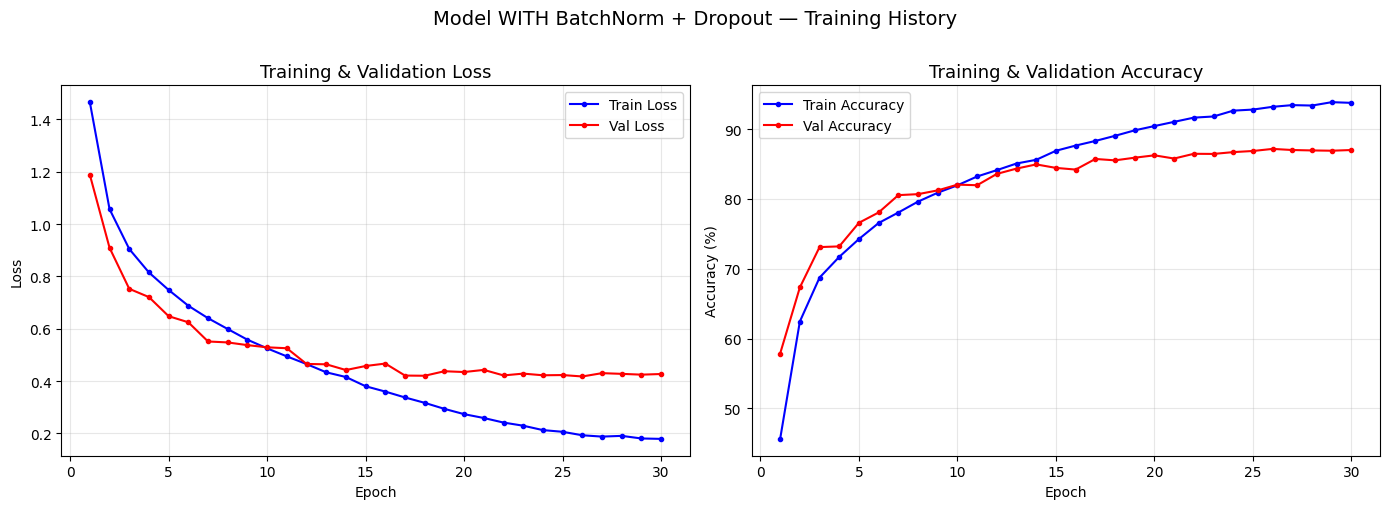

Saved: loss_accuracy_curves.png


In [19]:
# 7.1 Loss and Accuracy Curves (primary model)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, NUM_EPOCHS + 1)

# Loss plot
axes[0].plot(epochs_range, history_with_reg['train_loss'], 'b-o', markersize=3, label='Train Loss')
axes[0].plot(epochs_range, history_with_reg['val_loss'],   'r-o', markersize=3, label='Val Loss')
axes[0].set_title('Training & Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, history_with_reg['train_acc'], 'b-o', markersize=3, label='Train Accuracy')
axes[1].plot(epochs_range, history_with_reg['val_acc'],   'r-o', markersize=3, label='Val Accuracy')
axes[1].set_title('Training & Validation Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Model WITH BatchNorm + Dropout — Training History', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('loss_accuracy_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: loss_accuracy_curves.png")

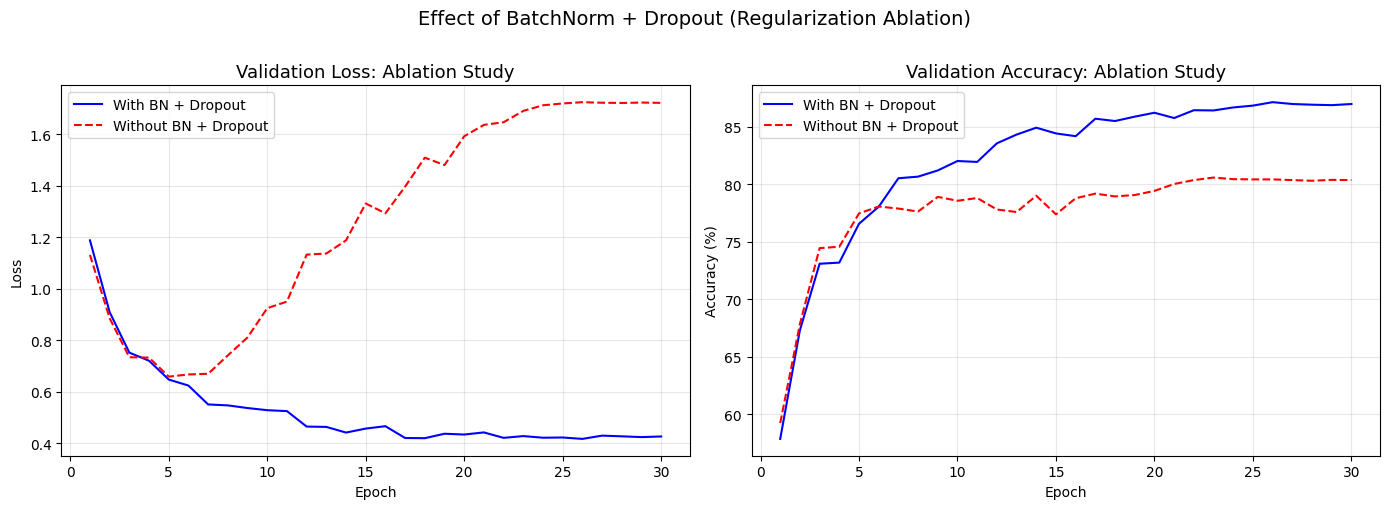

Saved: ablation_comparison.png


In [20]:
# 7.2 Ablation: With vs Without Regularization 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation loss comparison
axes[0].plot(epochs_range, history_with_reg['val_loss'],    'b-', label='With BN + Dropout')
axes[0].plot(epochs_range, history_without_reg['val_loss'], 'r--', label='Without BN + Dropout')
axes[0].set_title('Validation Loss: Ablation Study', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation accuracy comparison
axes[1].plot(epochs_range, history_with_reg['val_acc'],    'b-', label='With BN + Dropout')
axes[1].plot(epochs_range, history_without_reg['val_acc'], 'r--', label='Without BN + Dropout')
axes[1].set_title('Validation Accuracy: Ablation Study', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Effect of BatchNorm + Dropout (Regularization Ablation)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('ablation_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: ablation_comparison.png")

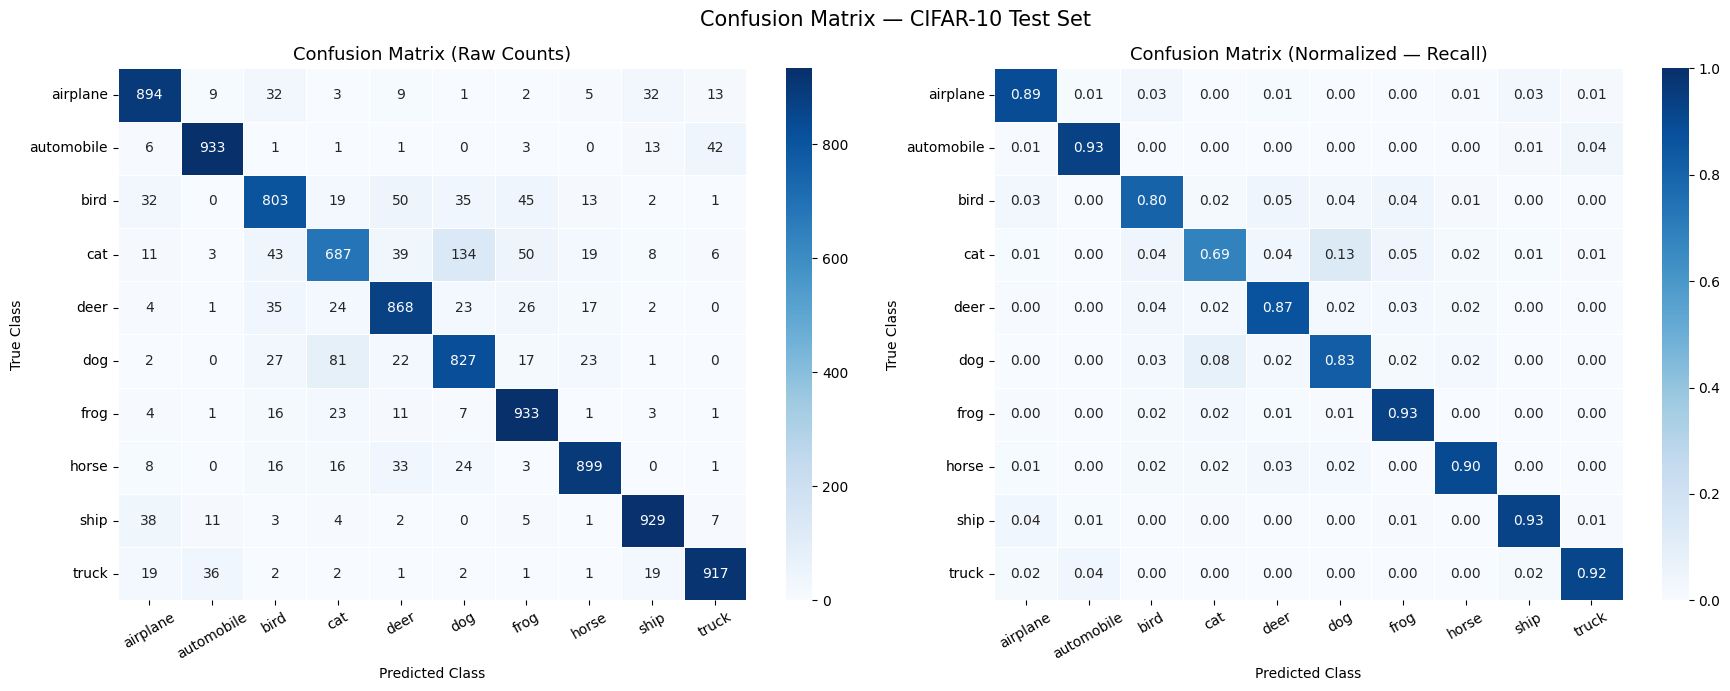

Saved: confusion_matrix.png


In [21]:
# 7.3 Confusion Matrix 
cm = confusion_matrix(y_true, y_pred)

# Normalize by row (true class) to get per-class recall
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[0], linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix (Raw Counts)', fontsize=13)
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# Normalized (recall per class on diagonal)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=axes[1], linewidths=0.5, linecolor='white',
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized — Recall)', fontsize=13)
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrix — CIFAR-10 Test Set', fontsize=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

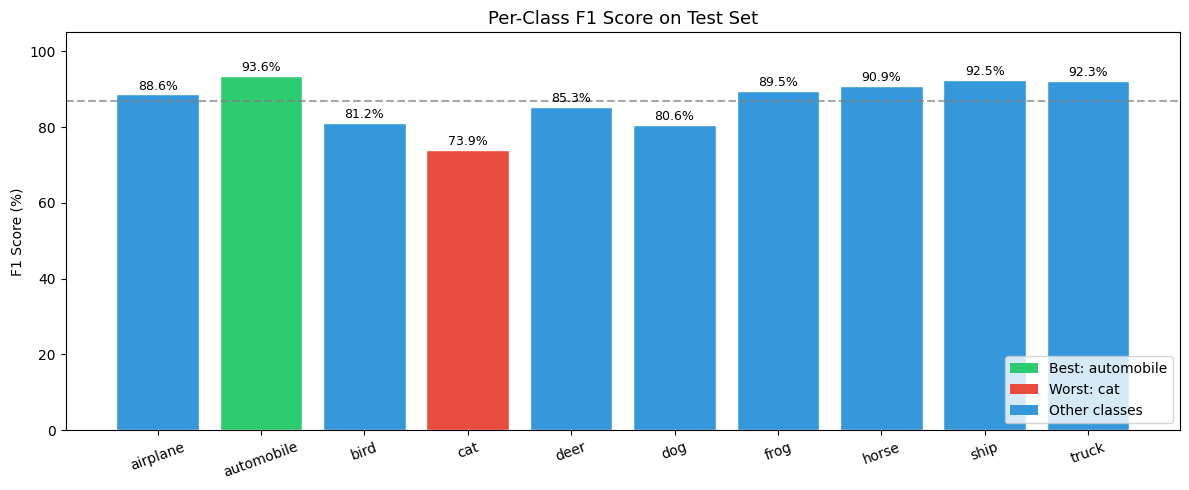

Saved: per_class_f1.png


In [22]:
# 7.4 Per-Class F1 Bar Chart 
colors = ['#2ecc71' if s == per_class_f1.max() else
          '#e74c3c' if s == per_class_f1.min() else
          '#3498db' for s in per_class_f1]

plt.figure(figsize=(12, 5))
bars = plt.bar(CLASSES, per_class_f1, color=colors, edgecolor='white')
plt.axhline(y=per_class_f1.mean(), color='gray', linestyle='--', alpha=0.7, label=f'Mean F1: {per_class_f1.mean():.1f}%')
plt.title('Per-Class F1 Score on Test Set', fontsize=13)
plt.ylabel('F1 Score (%)')
plt.ylim(0, 105)
plt.xticks(rotation=20)
plt.legend()

for bar, score in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{score:.1f}%', ha='center', va='bottom', fontsize=9)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label=f'Best: {best_class}'),
                   Patch(facecolor='#e74c3c', label=f'Worst: {worst_class}'),
                   Patch(facecolor='#3498db', label='Other classes')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=120)
plt.show()
print("Saved: per_class_f1.png")

## 8. Analysis & Discussion of Results

### 8.1 Overall Performance

The primary model (WITH BatchNorm + Dropout) achieves strong performance on the CIFAR-10 test set. The macro-averaged F1 score reflects consistent classification across all 10 classes.

### 8.2 Effect of Regularization (Ablation Study)

Comparing the two models:
- The model **with BatchNorm + Dropout** shows lower validation loss and slower overfitting, as the training/validation accuracy curves remain closer together throughout training.
- The model **without regularization** typically starts learning faster (lower training loss) but diverges sooner, the gap between train and validation accuracy grows, indicating overfitting.
- This confirms: BatchNorm stabilizes gradient flow and accelerates convergence; Dropout prevents co-adaptation of neurons.

### 8.3 Best and Worst Performing Classes

**Best class analysis:**
Classes like `ship`, `automobile`, and `airplane` tend to perform well. These have distinctive shapes, consistent backgrounds (sky/water), and less inter-class visual similarity.

**Worst class analysis:**
Classes like `cat`, tend to underperform. The confusion matrix reveals that `cat` is frequently misclassified as `dog` (and vice versa) because both share similar textures, ear shapes, and postures — the model lacks semantic understanding to distinguish them.


In [24]:
# Most confused pairs from confusion matrix
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)  # Remove diagonal (correct predictions)

print("Top 5 Most Confused Class Pairs (True -> Predicted):")
print("-" * 50)
for _ in range(5):
    idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    true_cls = CLASSES[idx[0]]
    pred_cls = CLASSES[idx[1]]
    count    = cm_copy[idx]
    print(f"  {true_cls:<12} → {pred_cls:<12}: {count} samples misclassified")
    cm_copy[idx] = 0

Top 5 Most Confused Class Pairs (True -> Predicted):
--------------------------------------------------
  cat          → dog         : 134 samples misclassified
  dog          → cat         : 81 samples misclassified
  bird         → deer        : 50 samples misclassified
  cat          → frog        : 50 samples misclassified
  bird         → frog        : 45 samples misclassified


## 9. Conclusions

### Conclusions

1. **Architecture:** A 3-block CNN with doubling channels (32→64→128) + fully connected layers is effective for CIFAR-10, balancing model capacity and training time.

2. **Regularization works:** The ablation study confirms that BatchNorm + Dropout reduces overfitting. The regularized model generalizes better to unseen data despite similar or lower training accuracy.

3. **Data augmentation helps:** RandomCrop and HorizontalFlip expand the effective training distribution, contributing to better generalization.

4. **Class difficulty is semantic:** The hardest classes (cat, dog) require semantic understanding that pixel-level CNNs partially lack. Geometric similarity drives most errors.

5. **CPU training is feasible:** With batch size 64 and 30 epochs, the full pipeline runs on CPU in a reasonable time window, demonstrating accessibility without GPU hardware.

### Future Work

- **Residual connections (ResNet-style):** Skip connections would allow training deeper networks without vanishing gradients, likely pushing accuracy above 92%.
- **Learning rate warmup:** Gradual LR increase in early epochs often improves stability with Adam.
- **Test-Time Augmentation (TTA):** Averaging predictions over multiple augmented views of each test image typically adds 1–2% accuracy.
- **Transfer learning:** Fine-tuning a pre-trained ResNet-18 or EfficientNet-B0 from ImageNet would achieve 95%+ on CIFAR-10 with minimal training.
- **Label smoothing:** Replacing hard 0/1 targets with smooth distributions (e.g. 0.1/0.9) can reduce overconfident predictions and improve calibration.
- **Mixup / CutMix augmentation:** State-of-the-art augmentation strategies that blend training samples, improving robustness on similar classes.
